In [2]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create the function and its derivative

In [3]:
# define a range for x
x = np.linspace(-2,2,2001)

# function (as a function)
def fx(x):
  return 3*x**2 - 3*x + 4

# derivative function
def deriv(x):
  return 6*x - 3

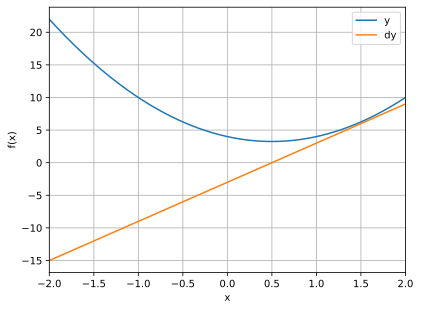

In [4]:
# plot the function and its derivative

# define a range for x
x = np.linspace(-2,2,2001)

# plotting
plt.plot(x,fx(x), x,deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y','dy'])
plt.show()

# Think about how to change the learning rate
1) Time (Training epoch)
2) Derivative
3) Loss
4) Current local minimum value



### G.D. using a fixed learning rate

[-1.38]


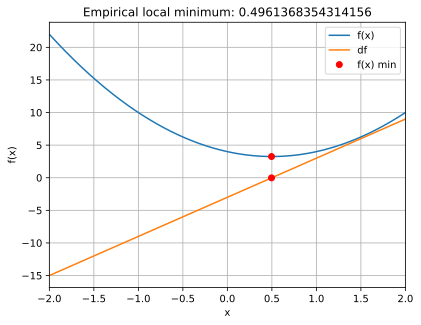

In [51]:
# random starting point
localmin = np.random.choice(x,1)
print(localmin)

# learning parameters
learning_rate = .01
training_epochs = 100

# run through training , this implements the gradient descent algorithm
for i in range(training_epochs):
  grad = deriv(localmin)
  localmin = localmin - learning_rate*grad

localmin
# plot the results

plt.plot(x,fx(x), x,deriv(x))
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin[0])
plt.show()

# 1) Dynamic learning rate Based on training epoch


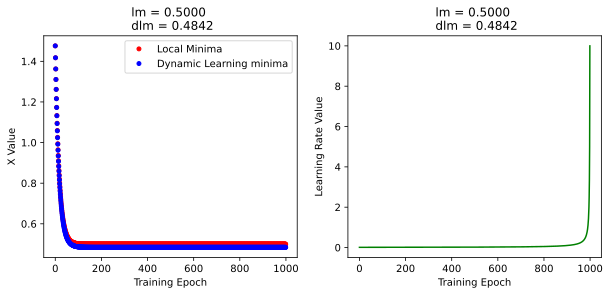

In [44]:
# 1) Dynamic learning rate Based on training epoch
# random starting point
localmin = np.random.choice(x,1)
dyn_loclamin = localmin

# learning parameters
learning_rate = .01
training_epochs = 1000
localmin_track = np.zeros(training_epochs)
dyn_localmin_track = np.zeros(training_epochs)
dyn_learning_track = np.zeros(training_epochs)


# run through training , this implements the gradient descent algorithm
for i in range(training_epochs):
  localmin_track[i] = localmin[0]
  dyn_localmin_track[i] = dyn_loclamin[0]
  grad = deriv(localmin)
  dyn_learning_rate = learning_rate / (1 - i/training_epochs)
  dyn_learning_track[i]= dyn_learning_rate
  localmin = localmin - learning_rate*grad  
  dyn_loclamin = dyn_loclamin - dyn_learning_rate*grad

# plot the learning rate dynamic value in a seperate sub plot
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(training_epochs),localmin_track,'ro',label='Local Minima',markersize=4)
ax[0].plot(range(training_epochs),dyn_localmin_track,'bo',label='Dynamic Learning minima',markersize=4)
ax[0].set_xlabel('Training Epoch')
ax[0].set_ylabel('X Value')
ax[0].set_title(f'lm = {localmin[0]:.4f} \n dlm = {dyn_loclamin[0]:.4f}')
ax[0].legend(loc='best')
ax[1].plot(range(training_epochs),dyn_learning_track,'g-',label='Dynamic Learning Rate Value',markersize=4)
ax[1].set_xlabel('Training Epoch')
ax[1].set_ylabel('Learning Rate Value')
ax[1].set_title(f'lm = {localmin[0]:.4f} \n dlm = {dyn_loclamin[0]:.4f}')
plt.show()

# 2) Dynamic learning rate Based on derivative


C:\Users\arumu\AppData\Local\Temp\ipykernel_28552\1524223069.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dyn_learning_track[i]= dyn_learning_rate


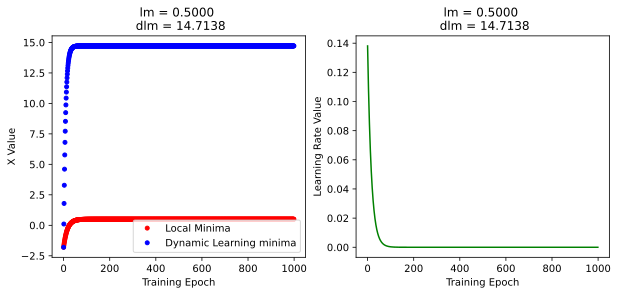

In [ ]:
# random starting point
localmin = np.random.choice(x,1)
initval = localmin[:] # store the initial value

# learning parameters
learning_rate = .01
training_epochs = 50

# run through training and store all the results
modelparamsFixed = np.zeros((training_epochs,3))
for i in range(training_epochs):
  
  # compute gradient
  grad = deriv(localmin)

  # non-adaptive learning rate
  lr = learning_rate

  # update parameter according to g.d.
  localmin = localmin - lr*grad

  # store the parameters
  modelparamsFixed[i,:] = localmin,grad,lr
  
# plot results

# 3) Dynamic learning rate Based on loss


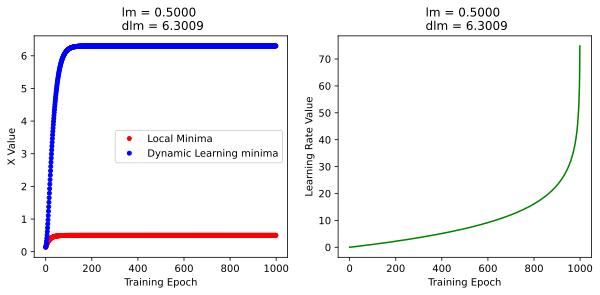

In [47]:
# 3) Dynamic learning rate Based on loss
# random starting point
localmin = np.random.choice(x,1)
dyn_loclamin = localmin

# learning parameters
learning_rate = .01
training_epochs = 1000
localmin_track = np.zeros(training_epochs)
dyn_localmin_track = np.zeros(training_epochs)
dyn_learning_track = np.zeros(training_epochs)


# run through training , this implements the gradient descent algorithm
for i in range(training_epochs):
  localmin_track[i] = localmin[0]
  dyn_localmin_track[i] = dyn_loclamin[0]
  grad = deriv(localmin)
  if i > 0:
    dyn_learning_rate = dyn_learning_track[i-1] + (learning_rate / (1 - i/training_epochs))
  else:
    dyn_learning_rate = learning_rate / (1 - i/training_epochs)
  dyn_learning_track[i]= dyn_learning_rate
  localmin = localmin - learning_rate*grad  
  dyn_loclamin = dyn_loclamin - dyn_learning_rate*grad

# plot the learning rate dynamic value in a seperate sub plot
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(training_epochs),localmin_track,'ro',label='Local Minima',markersize=4)
ax[0].plot(range(training_epochs),dyn_localmin_track,'bo',label='Dynamic Learning minima',markersize=4)
ax[0].set_xlabel('Training Epoch')
ax[0].set_ylabel('X Value')
ax[0].set_title(f'lm = {localmin[0]:.4f} \n dlm = {dyn_loclamin[0]:.4f}')
ax[0].legend(loc='best')
ax[1].plot(range(training_epochs),dyn_learning_track,'g-',label='Dynamic Learning Rate Value',markersize=4)
ax[1].set_xlabel('Training Epoch')
ax[1].set_ylabel('Learning Rate Value')
ax[1].set_title(f'lm = {localmin[0]:.4f} \n dlm = {dyn_loclamin[0]:.4f}')
plt.show()